<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 36px; border-radius: 12px; color: white; font-family: 'Segoe UI', sans-serif;">
<div style="font-size: 13px; color: #a0c4ff; letter-spacing: 2px; text-transform: uppercase; margin-bottom: 8px;">TripleTen · Sprint 12 · Webinar 3</div>
<h1 style="margin: 0 0 8px 0; font-size: 36px; font-weight: 800;">🧪 Implementación de nuevas funciones</h1>
<p style="margin: 0; font-size: 17px; color: #90caf9;">Pruebas A/B · Valor p · Intervalos de confianza · Bootstrap</p>
<hr style="border: none; border-top: 1px solid #ffffff22; margin: 24px 0;">
<table style="width: 100%; border-collapse: collapse; font-size: 14px;">
<tr>
  <td style="padding: 6px 12px; color: #a0c4ff;">⏱️ Tipo de webinar</td>
  <td style="padding: 6px 12px; color: #fff;">Teoría </td>
  <td style="padding: 6px 12px; color: #a0c4ff;">🛠️ Herramientas</td>
  <td style="padding: 6px 12px; color: #fff;">VsCode</td>
</tr>
<tr>
  <td style="padding: 6px 12px; color: #a0c4ff;">📦 Dataset</td>
  <td style="padding: 6px 12px; color: #fff;">E-commerce ficticio</td>
  <td style="padding: 6px 12px; color: #a0c4ff;">🎯 Nivel</td>
  <td style="padding: 6px 12px; color: #fff;">Intermedio</td>
</tr>
</table>
</div>

## 🗺️ Agenda de hoy

| # | Bloque |
|---|--------|
| 1 | Peeking problem en vivo | 
| 2 | Prueba A/A + bug hunt | 
| 3 | Prueba A/B + intervalos de confianza | 
| 4 | Bootstrap |

## 🎯 Al terminar vas a poder...
- ✅ Explicar qué es el peeking problem y por qué arruina un experimento
- ✅ Correr una prueba A/A antes de una A/B
- ✅ Calcular valor p e intervalo de confianza con `scipy`
- ✅ Usar bootstrap cuando los datos no son normales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

np.random.seed(42)

---
# PARTE 1 — El peeking problem

Vamos a reproducirlo. Ambos grupos tienen **la misma tasa de conversión** — H₀ es verdadera. Si miramos el p-valor en cada paso, ¿cuántas veces nos mentiría?

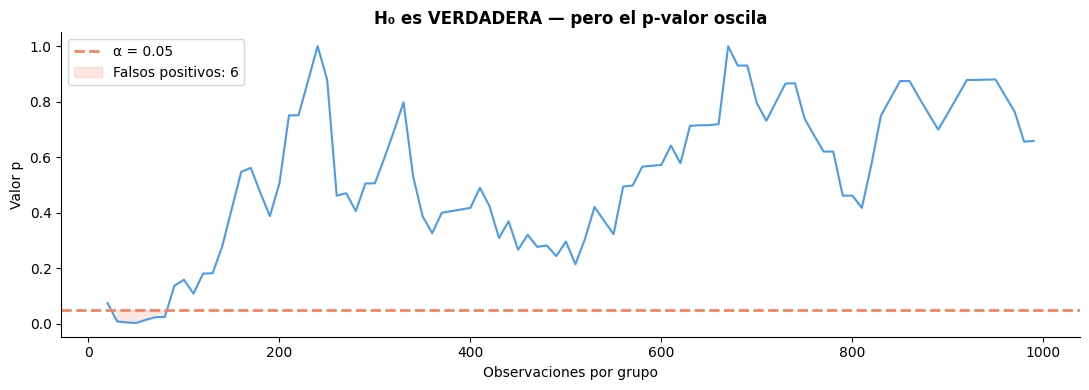

Veces que p < 0.05 con H₀ verdadera: 6 de 98
Tasa de error: 6.1%  (debería ser ~5%)


In [21]:
n_total = 1000
grupo_A = np.random.binomial(1, 0.10, n_total)
grupo_B = np.random.binomial(1, 0.10, n_total)

pvalues = []
pasos = range(20, n_total, 10)

for n in pasos:
    _, p = st.ttest_ind(grupo_A[:n], grupo_B[:n])
    pvalues.append(p)

falsos_positivos = sum(1 for p in pvalues if p < 0.05)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(list(pasos), pvalues, color='#4C9BE8', linewidth=1.5)
ax.axhline(0.05, color='#F4845F', linestyle='--', linewidth=2, label='α = 0.05')
ax.fill_between(list(pasos), pvalues, 0.05,
                where=[p < 0.05 for p in pvalues],
                color='#F4845F', alpha=0.2, label=f'Falsos positivos: {falsos_positivos}')
ax.set_xlabel('Observaciones por grupo')
ax.set_ylabel('Valor p')
ax.set_title('H₀ es VERDADERA — pero el p-valor oscila', fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Veces que p < 0.05 con H₀ verdadera: {falsos_positivos} de {len(pvalues)}')
print(f'Tasa de error: {falsos_positivos/len(pvalues):.1%}  (debería ser ~5%)')

---
# PARTE 2 — Prueba A/A

Antes de cualquier A/B, validamos que los grupos son equivalentes. Si no lo son, hay un error en la asignación — no en el producto.

In [22]:
aa_g1 = np.random.normal(50, 10, 200)
aa_g2 = np.random.normal(50, 10, 200)

stat, p_aa = st.ttest_ind(aa_g1, aa_g2, alternative='two-sided')

if p_aa > 0.05:
    print(f'✅ Grupos equivalentes (p={p_aa:.3f}) — podemos proceder con A/B')
else:
    print(f'❌ Grupos ya son diferentes antes del experimento (p={p_aa:.3f}) — revisar asignación')

✅ Grupos equivalentes (p=0.136) — podemos proceder con A/B


---
# PARTE 3 — Prueba A/B + Intervalo de confianza

Probamos un nuevo flujo de onboarding. Hipótesis: el nuevo es más rápido.

- H₀: tiempo B ≥ tiempo A (no mejora)
- H₁: tiempo B < tiempo A (sí mejora)

In [23]:
n = 300
control     = np.random.normal(45, 12, n).clip(5)
experimento = np.random.normal(38, 11, n).clip(5)

stat, pval = st.ttest_ind(experimento, control, alternative='less')

print(f'Control:     {control.mean():.1f} min')
print(f'Experimento: {experimento.mean():.1f} min')
print(f'Diferencia:  {control.mean() - experimento.mean():.1f} min')
print(f'p-valor:     {pval:.5f}')
print()
print('✅ Se rechaza H₀' if pval < 0.05 else '⚠️ No se rechaza H₀')

Control:     42.8 min
Experimento: 38.0 min
Diferencia:  4.8 min
p-valor:     0.00000

✅ Se rechaza H₀


IC 90% Control:     (41.6, 44.0) min
IC 90% Experimento: (36.9,  39.1) min


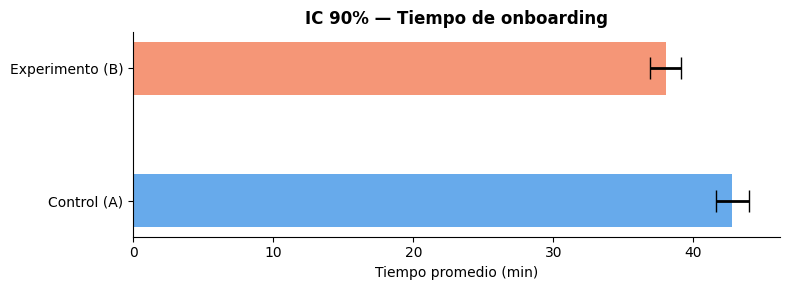

In [24]:
ic_ctrl = st.t.interval(0.90, df=len(control)-1,     loc=control.mean(),     scale=st.sem(control))
ic_exp  = st.t.interval(0.90, df=len(experimento)-1, loc=experimento.mean(), scale=st.sem(experimento))

print(f'IC 90% Control:     ({ic_ctrl[0]:.1f}, {ic_ctrl[1]:.1f}) min')
print(f'IC 90% Experimento: ({ic_exp[0]:.1f},  {ic_exp[1]:.1f}) min')

fig, ax = plt.subplots(figsize=(8, 3))
grupos = ['Control (A)', 'Experimento (B)']
medias = [control.mean(), experimento.mean()]
err_inf = [medias[0]-ic_ctrl[0], medias[1]-ic_exp[0]]
err_sup = [ic_ctrl[1]-medias[0], ic_exp[1]-medias[1]]
ax.barh(grupos, medias, xerr=[err_inf, err_sup],
        color=['#4C9BE8','#F4845F'], alpha=0.85, height=0.4,
        error_kw={'ecolor':'black','capsize':8,'linewidth':2})
ax.set_xlabel('Tiempo promedio (min)')
ax.set_title('IC 90% — Tiempo de onboarding', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

---
# PARTE 4 — Bootstrap

¿la diferencia que observé entre A y B pudo haber pasado por pura suerte?

Mismo experimento, pero sin asumir normalidad. Remuestreamos con reemplazo para construir la distribución del p-valor empíricamente.

In [29]:
diff_real = experimento.mean() - control.mean()
unidos    = np.concatenate([control, experimento])

diffs_boot = [
    np.random.permutation(unidos)[:len(control)].mean() -
    np.random.permutation(unidos)[len(control):].mean()
    for _ in range(1000)
]

stat, p_boot = st.ttest_ind(experimento, control, alternative='less')

print(f'Diferencia real:   {diff_real:.2f} min')
print(f'p-valor bootstrap: {p_boot:.4f}')
print('✅ Se rechaza H₀' if p_boot < 0.05 else '⚠️ No se rechaza H₀')

Diferencia real:   -4.78 min
p-valor bootstrap: 0.0000
✅ Se rechaza H₀


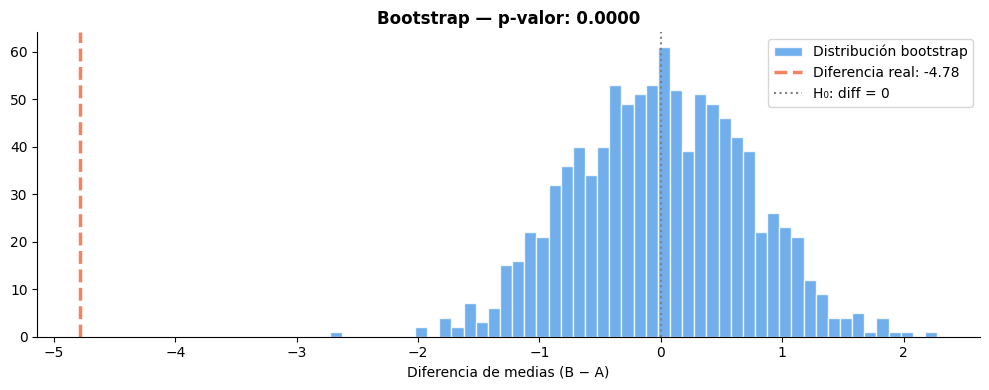

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(diffs_boot, bins=50, color='#4C9BE8', alpha=0.8, edgecolor='white', label='Distribución bootstrap')
ax.axvline(diff_real, color='#F4845F', linewidth=2.5, linestyle='--', label=f'Diferencia real: {diff_real:.2f}')
ax.axvline(0, color='gray', linewidth=1.5, linestyle=':', label='H₀: diff = 0')
ax.set_xlabel('Diferencia de medias (B − A)')
ax.set_title(f'Bootstrap — p-valor: {p_boot:.4f}', fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

---
# 🏆 Reto grupal — 10 minutos

Una empresa quiere saber si su nuevo sistema de recomendaciones aumentó el ticket promedio.

- Grupo A (control): media = $42, std = $15, n = 250
- Grupo B (experimento): media = $47, std = $16, n = 250

1. Corre la prueba A/A primero
2. Corre la prueba A/B con `alternative='greater'`
3. Calcula IC al 95% para ambos grupos
4. **Bonus:** ¿Qué pasa si reduces n a 30? ¿Cambia la conclusión?

Reporta en el chat: p-valor, ¿se rechaza H₀?, IC del grupo B.

In [ ]:
np.random.seed(99)
# Tu código aquí 👇


---
# 📝 Resumen

| Concepto | Clave |
|---|---|
| **Peeking problem** | Mirar el p-valor antes de tiempo infla los falsos positivos |
| **Prueba A/A** | Verificar que los grupos son equivalentes antes del experimento → `two-sided` |
| **Valor p** | Probabilidad de ver estos datos si H₀ fuera verdadera. Umbral: 5% |
| **Error tipo I** | Falso positivo — lanzar algo que no funciona |
| **Error tipo II** | Falso negativo — no lanzar algo que sí funciona |
| **IC con t.interval** | `df=n-1`, `loc=media`, `scale=sem` |
| **Bootstrap** | Para datos no normales. Remuestrear con reemplazo, calcular diferencia, contar |

---
### 🔙 Volvamos al caso del inicio

> El PM quería lanzar el viernes con 2 días de datos.

**No.** Con tan pocas observaciones, la varianza es alta y el p-valor oscila mucho (lo vimos en la Parte 1). El tamaño de muestra debería haberse definido **antes** de arrancar el experimento, no después de que el p-valor baje.